# Vanilla Policy Gradients
Policy gradients using gae and value function baseline.

obs, actions: 4, 2
Sequential(
  (0): Linear(in_features=4, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=2, bias=True)
)
Sequential(
  (0): Linear(in_features=4, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=1, bias=True)
)
0 27.210526315789473 38
1 31.90909090909091 33
2 52.5 20
3 66.5 16
4 67.5625 16
5 94.63636363636364 11
6 210.6 5
7 389.6666666666667 3
8 365.0 4
9 378.0 3
10 500.0 3
11 429.6666666666667 3
12 237.6 5
13 251.2 5
14 310.25 4
15 314.75 4
16 175.14285714285714 7
17 148.71428571428572 7
18 156.57142857142858 7
19 61.611111111111114 18
20 52.35 20
21 70.26666666666667 15
22 105.4 10
23 125.88888888888889 9
24 187.0 6
25 500.0 3
26 500.0 3
27 500.0 3
28 500.0 3
29 500.0 3
30 500.0 3
31 500.0 3
32 500.0 3
33 500.0 3
34 500.0 3
35 500.0 3
36 500.0 3
37 500.0 3
38 500.0 3
39 500.0 3
40 500.0 3
41 500.0 3
42 500.0 3
43 500.0 3
44 500.0 3
45 500.0 3
46 500.0 3
47 500.0 3
48 500.0 3
49 500.0 3
50 500.

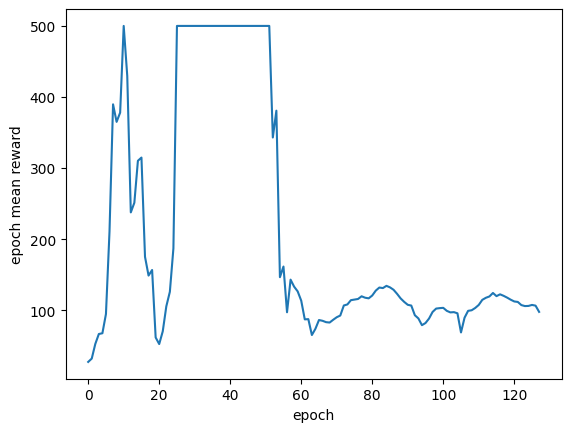

In [1]:
import gymnasium as gym
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
from torch.optim import Adam
from torch.distributions import Categorical

def build_mlp(sizes: list[int]):
    layers = []
    for i in range(len(sizes)-1):
        layers.append(nn.Linear(sizes[i], sizes[i+1]))
        if i != len(sizes) - 2: layers.append(nn.ReLU())
    return nn.Sequential(*layers)

def discount_cumsum(x: np.ndarray, discount_factor: float) -> np.ndarray:
    x = x.copy()
    for i in range(len(x) - 2, -1, -1):
        x[i] += discount_factor * x[i+1]
    return x

N_EPOCHS = 128
BATCH_SIZE = 1024
DEVICE = "cpu"
POLICY_LR = 1e-1
VALUE_FUNC_LR = 1e-1
VALUE_FUNC_OPTIM_STEPS = 1
DISCOUNT_GAMMA = 0.99
GAE_LAMBDA = 0.95

env = gym.make("CartPole-v1")
n_obs = env.observation_space.shape[0]
n_actions = int(env.action_space.n)
print(f"obs, actions: {n_obs}, {n_actions}")

policy = build_mlp([n_obs, 32, n_actions])
policy.to(DEVICE)
print(policy)

value_func = build_mlp([n_obs, 32, 1])
value_func.to(DEVICE)
print(value_func)

policy_optim = Adam(policy.parameters(), lr=POLICY_LR)
value_func_optim = Adam(value_func.parameters(), lr=VALUE_FUNC_LR)

epoch_mean_rewards = []
for epoch in range(N_EPOCHS):
    total_rewards = []

    # Sample episode. Collect action log probs and rewards.
    obss = []
    log_probs = []
    advantages = []
    rewards_to_go = []

    while len(log_probs) < BATCH_SIZE:
        episode_rewards = []
        episode_obss = []

        obs, _ = env.reset()
        while True:
            obs = torch.tensor(obs, dtype=torch.float32, device=DEVICE)
            episode_obss.append(obs)

            logits = policy(obs.unsqueeze(0))[0]

            action_dist = Categorical(logits=logits)
            action = action_dist.sample()
            log_probs.append(action_dist.log_prob(action))

            obs, reward, terminated, truncated, _ = env.step(action.item())
            episode_rewards.append(reward)

            if terminated or truncated:
                break

        total_rewards.append(sum(episode_rewards))

        # GAE.
        episode_obss = torch.stack(episode_obss, dim=0)
        obss.append(episode_obss)
        with torch.no_grad():
            values = value_func(episode_obss).squeeze(-1).cpu().numpy()

        episode_rewards = np.array(episode_rewards, dtype=np.float32)
        td_deltas = episode_rewards - values
        td_deltas[:-1] += DISCOUNT_GAMMA * values[1:]
        gaes = discount_cumsum(td_deltas, DISCOUNT_GAMMA * GAE_LAMBDA)
        advantages.append(torch.tensor(gaes, dtype=torch.float32, device=DEVICE))

        # Rewards to go.
        rtgs = discount_cumsum(episode_rewards, DISCOUNT_GAMMA)
        rewards_to_go.append(torch.tensor(rtgs, dtype=torch.float32, device=DEVICE))

    # Normalize advantage.
    advantages = torch.cat(advantages, dim=0)
    advantages = (advantages - advantages.mean()) / advantages.std()

    # Optimize policy.
    log_probs = torch.stack(log_probs)
    policy_loss = -(log_probs * advantages).mean()

    policy_optim.zero_grad()
    policy_loss.backward()
    policy_optim.step()

    # Optimize value function.
    obss = torch.cat(obss, dim=0)
    rewards_to_go = torch.cat(rewards_to_go, dim=0)
    for _ in range(VALUE_FUNC_OPTIM_STEPS):
        value_func_loss = F.mse_loss(value_func(obss).squeeze(-1), rewards_to_go)
        value_func_optim.zero_grad()
        value_func_loss.backward()
        value_func_optim.step()

    # Log.
    epoch_mean_reward = sum(total_rewards) / len(total_rewards)
    epoch_mean_rewards.append(epoch_mean_reward)
    print(epoch, epoch_mean_reward, len(total_rewards))

plt.plot(epoch_mean_rewards)
plt.xlabel("epoch")
plt.ylabel("epoch mean reward")
plt.show()